In [24]:
import pandas as pd
from catboost import CatBoostClassifier
from catboost import Pool
from sklearn.model_selection import train_test_split

In [20]:
df = pd.read_csv('../data/friends_features.csv', index_col='user_id')
df.sample(5)

,friend_id,is_friend,common_friends_count,demographics_sex_user,demographics_age_user,demographics_city_user,education_career_education_university_user,education_career_education_faculty_user,demographics_sex_friend,demographics_age_friend,demographics_city_friend,education_career_education_university_friend,education_career_education_faculty_friend
user_id,,,,,,,,,,,,,
466579963,221280561,True,2,мужской,22.0,Москва,Неизвестно,Неизвестно,женский,22.0,Химки,Неизвестно,Неизвестно
185888968,342243498,True,2,мужской,22.0,Москва,Неизвестно,Неизвестно,мужской,22.0,Москва,Неизвестно,Неизвестно
395645310,112120311,True,1,мужской,22.0,Москва,Неизвестно,Неизвестно,мужской,22.0,Москва,Неизвестно,Неизвестно
439146588,365320601,True,2,мужской,22.0,Москва,РТУ МИРЭА,Институт информационных технологий,женский,22.0,Москва,МИРЭА (до 2015),Факультет информационных технологий
265111970,174111046,True,3,мужской,22.0,Москва,РТУ МИРЭА,Институт информационных технологий,женский,22.0,Москва,Неизвестно,Неизвестно


In [31]:
df['is_friend'].value_counts()

is_friend
True     774
False    438
Name: count, dtype: int64

In [36]:
X = df.drop(columns=['friend_id', 'is_friend'])
y = df['is_friend']

cat_features = ['demographics_sex_user',
                'demographics_city_user',
                'education_career_education_university_user',
                'education_career_education_faculty_user',
                'demographics_sex_friend',
                'demographics_city_friend',
                'education_career_education_university_friend',
                'education_career_education_faculty_friend']

X_train, X_test, y_train, y_test= train_test_split(X, y, train_size=0.8, random_state=42, shuffle=True)

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(969, 11)
(969,)
(243, 11)
(243,)


In [ ]:
model = CatBoostClassifier(iterations=500,
                           learning_rate=0.01,
                           depth=8,
                           loss_function='Logloss',
                           eval_metric='Accuracy',
                           cat_features=cat_features,
                           random_seed=42,
                           task_type='GPU',
                           devices='0',
                           verbose=50)

In [38]:
model.fit(X_train, y_train, eval_set=(X_test, y_test))

0:	learn: 0.8111455	test: 0.7489712	best: 0.7489712 (0)	total: 134ms	remaining: 1m 6s
50:	learn: 0.8111455	test: 0.7489712	best: 0.7489712 (0)	total: 2.5s	remaining: 22s
100:	learn: 0.8400413	test: 0.8024691	best: 0.8024691 (81)	total: 4.82s	remaining: 19s
150:	learn: 0.8421053	test: 0.7983539	best: 0.8024691 (81)	total: 6.96s	remaining: 16.1s
200:	learn: 0.8410733	test: 0.8024691	best: 0.8024691 (81)	total: 9.17s	remaining: 13.6s
250:	learn: 0.8410733	test: 0.8024691	best: 0.8024691 (81)	total: 11.2s	remaining: 11.1s
300:	learn: 0.8410733	test: 0.8024691	best: 0.8024691 (81)	total: 13.2s	remaining: 8.73s
350:	learn: 0.8410733	test: 0.8024691	best: 0.8024691 (81)	total: 15.3s	remaining: 6.5s
400:	learn: 0.8441692	test: 0.8024691	best: 0.8024691 (81)	total: 17.5s	remaining: 4.33s
450:	learn: 0.8452012	test: 0.8024691	best: 0.8024691 (81)	total: 19.8s	remaining: 2.15s
499:	learn: 0.8462332	test: 0.8106996	best: 0.8106996 (479)	total: 21.7s	remaining: 0us
bestTest = 0.8106995885
bestItera

In [40]:
print("Accuracy:", model.score(X_test, y_test))


Accuracy: 0.8106995884773662


In [82]:
new_data = pd.DataFrame([{
    "common_friends_count": 0,
    "demographics_sex_user": "мужской",
    "demographics_age_user": 25.0,
    "demographics_city_user": "Москва",
    "education_career_education_university_user": "Неизвестно",
    "education_career_education_faculty_user": "Неизвестно",
    "demographics_sex_friend": "женский",  
    "demographics_age_friend": 24.0,       
    "demographics_city_friend": "Москва",  
    "education_career_education_university_friend": "Неизвестно",  
    "education_career_education_faculty_friend": "Неизвестно"   
}])

new_data = new_data[X_train.columns]

pred = model.predict(new_data)
print("Предсказание (0 = не друг, 1 = друг):", pred)

prob = model.predict_proba(new_data)
print("Вероятность дружбы:", prob[0][1])

Предсказание (0 = не друг, 1 = друг): [False]
Вероятность дружбы: 0.2677930395110051


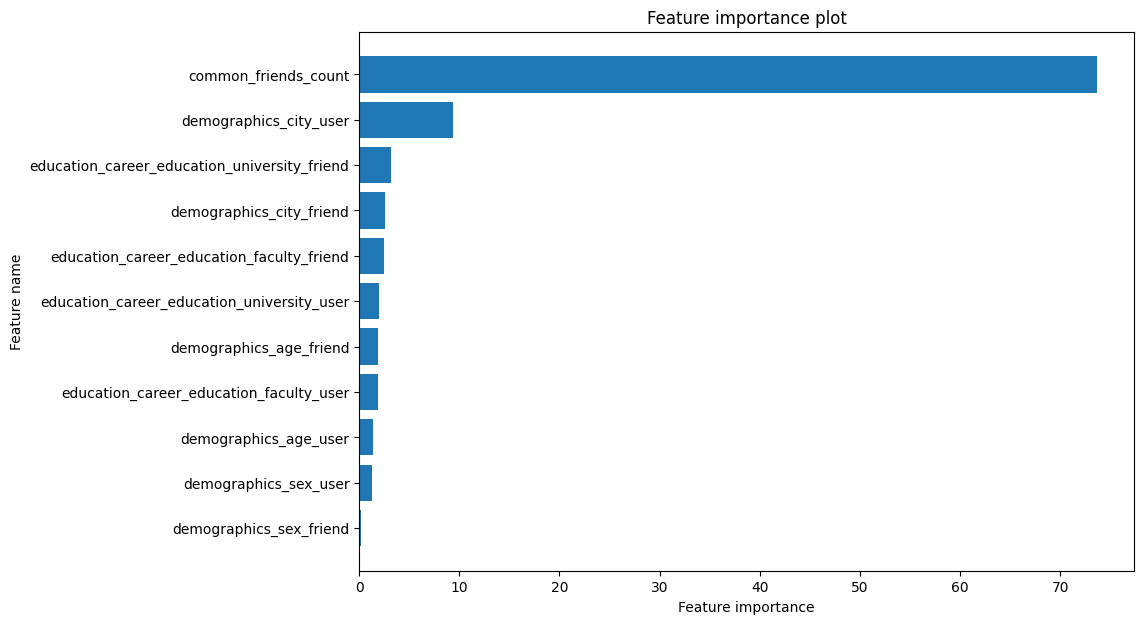

In [75]:
import matplotlib.pyplot as plt


feature_importance = model.get_feature_importance()
feature_names = X_train.columns

importance_df = pd.DataFrame({'feature_name': feature_names,
                              'feature_importance': feature_importance}).sort_values(by='feature_importance', ascending=True)

plt.figure(figsize=(10,7))
plt.barh(importance_df['feature_name'], importance_df['feature_importance'])
plt.ylabel('Feature name')
plt.xlabel('Feature importance')
plt.title('Feature importance plot')
# plt.xticks(rotation=45, ha='right')
plt.show()